# Imports

In [1]:
from torch.utils.data import DataLoader, random_split
import torch
from data import ParenthesizationDataset, ParenthesizationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Initialization
Set the parameters here for training and initialize the train/test datasets, data loaders, model, loss function and optimizer.

In [2]:
n = 7
epochs = 50
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 32

# TODO: Create the datasets, model, loss function, optimizer, and data loader.
dataset = ParenthesizationDataset(n)
training_dataset, test_dataset = random_split(dataset, [train_split, test_split])
model = ParenthesizationModel(n)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
DataLoader = DataLoader(dataset, batch_size, shuffle=True)

# Training the model
* Call `train_one_epoch` repeatedly to train the model once over the entire training dataset.
* Print out the epoch number and loss after each training call to verify that the loss is going down.
* Record the loss values in a list so that it can be plotted in the cell below.
* After training, call `evaluate_model` to get the confusion matrix.
* Save the model as `models/linear_model_{n}.pt`.

In [3]:
loss = []
for epoch in range(epochs):
    # TODO

    # Train one epoch
    train_loss = train_one_epoch(DataLoader, model, loss_fn, optimizer)
    
    # Add the loss
    loss.append(train_loss)

    # Print Epoch and Loss
    print(epoch, loss[-1])

# Save the model as models/linear_model_{n}.pt
torch.save(model.state_dict(), f"models/linear_model_{n}.pt")



0 20.45659351348877
1 18.866756975650787
2 17.603737473487854
3 16.5424365401268
4 15.637289762496948
5 14.89599785208702
6 14.239937514066696
7 13.66605344414711
8 13.18812119960785
9 12.774825483560562
10 12.380259215831757
11 12.07928928732872
12 11.764421880245209
13 11.49647805094719
14 11.261568933725357
15 11.045604884624481
16 10.856510758399963
17 10.65700113773346
18 10.505572438240051
19 10.341237276792526
20 10.221503421664238
21 10.084489524364471
22 9.956348478794098
23 9.838350176811218
24 9.751550167798996
25 9.627270519733429
26 9.518856883049011
27 9.449035942554474
28 9.350357711315155
29 9.260515585541725
30 9.222124949097633
31 9.141192093491554
32 9.067381218075752
33 8.98832206428051
34 8.9561517983675
35 8.876370310783386
36 8.818852871656418
37 8.761572077870369
38 8.726794198155403
39 8.661105394363403
40 8.621050477027893
41 8.599766984581947
42 8.51764626801014
43 8.488773763179779
44 8.456155359745026
45 8.414362609386444
46 8.37993098795414
47 8.3209083378

# Plot the loss curve
Plot the loss curve with appropriate figure title and axis labels. Save the resulting figure in `figures/loss_curve_{n}.png`.

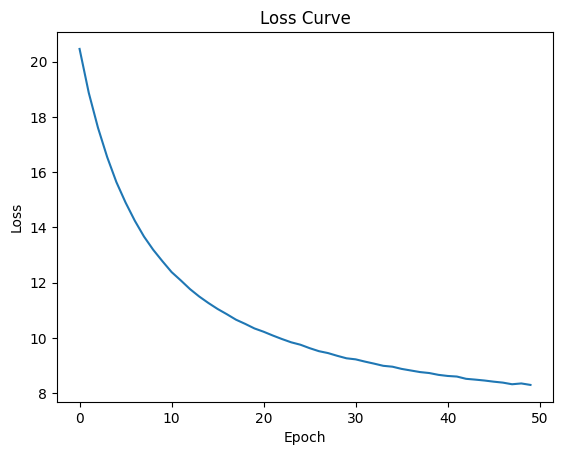

In [4]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(loss)), loss)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

# Show the plot
plt.show()

fig.savefig(f'figures/loss_curve_{n}.png', dpi=300)

# Analyze accuracy using the confusion matrix
- Print out the accuracy within each of the prediction classes.
- Print out the size of each prediction class.
- Print out the overall accuracy.

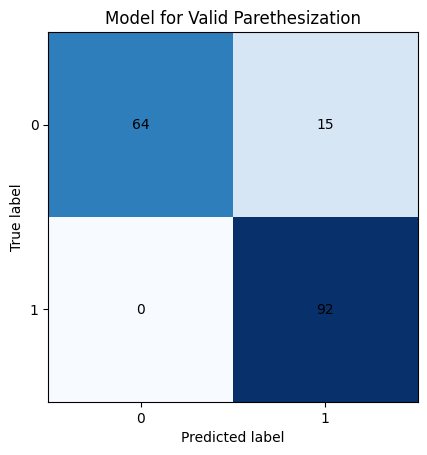

True Invalid: 100.0% ; Size : 64
False Invalid:0.0%; Size : 0
False Valid:14.02%; Size : 15
True Valid:85.98%; Size : 92
Overall accuracy: 91.23%; 


In [5]:
# TODO
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
plt.imshow(confusion_matrix, cmap="Blues")
plt.xticks(range(len(confusion_matrix)), range(len(confusion_matrix)))
plt.yticks(range(len(confusion_matrix)), range(len(confusion_matrix)))
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(len(confusion_matrix)):
    for j in range(len(confusion_matrix)):
        plt.text(j, i, confusion_matrix[i][j], ha="center", va="center")
plt.title("Model for Valid Parethesization")
plt.show()

print("True Invalid: " + str(round (100 * (confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "% ; " + "Size : " +  str(confusion_matrix[0][0]))
print("False Invalid:" + str(round (100 * (confusion_matrix[1][0] / (confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "%; " + "Size : " +  str(confusion_matrix[1][0]))
print("False Valid:" + str(round (100 * (confusion_matrix[0][1] / (confusion_matrix[0][1] + confusion_matrix[1][1])), 2)) + "%; " + "Size : " +  str(confusion_matrix[0][1]))
print("True Valid:" + str(round (100 * (confusion_matrix[1][1] / (confusion_matrix[0][1] + confusion_matrix[1][1])), 2)) + "%; " + "Size : " +  str(confusion_matrix[1][1]))
print("Overall accuracy: " + str(round (100 * ((confusion_matrix[1][1] + confusion_matrix[0][0]) / (confusion_matrix[0][1] + confusion_matrix[1][1] + confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "%; ")




# Plot the model weights
Can you interpret what the model is doing? Plot the model weights using `plt.imshow()` to get a heatmap. Choose a colormap from https://matplotlib.org/stable/users/explain/colors/colormaps.html that you prefer. I default to the `bwr` colormap where negative values are blue, positive value are red, and values close to zero are white.

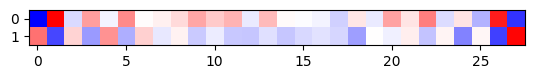

In [6]:
# TODO
weights = model.fc.weight.detach().numpy()
plt.imshow(weights, cmap="bwr")

# It appears that the model checks the first and last parantheses such that if the first is close ie ")" then the model will likley say its invalid.
# If last is open ie "(" then the model will likely say its also invalid

# "Translate" the model into code.
Implement `simple_evaluate` which condenses the model's "logic" into a single if-else statement. Run this evaluation function over the test set to produce a new confusion matrix and see how it performs compared to the model you train.

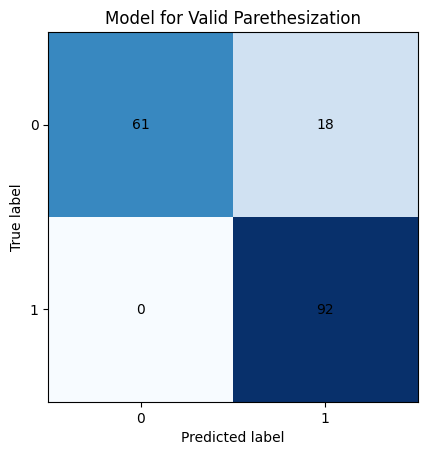

True Invalid: 100.0% ; Size : 61
False Invalid:0.0%; Size : 0
False Valid:16.36%; Size : 18
True Valid:83.64%; Size : 92
Overall accuracy: 89.47%; 
We can see our simple model and pytorch model are relativley similar when it comes to the results


In [8]:
# Try to condense the linear model down into a single if-else statement. 
def simple_evaluate(input):
    # TODO
    confusion_matrix = [[0, 0], [0, 0]]
    # TODO
    for data in input:
        test_input, label = data
        #var = (test_input[0])
        #var2 = (test_input[-1])
        if (test_input[0] == 0 or test_input[-1] == 0):
            # Invalid
            output = 0
        else:
            output = 1
        confusion_matrix[label][output] += 1
        #confusion_matrix[label][torch.argmax(outputs)] += 1

    return confusion_matrix

confusion_matrix = simple_evaluate(test_dataset)

# Print the confusion matrix
plt.imshow(confusion_matrix, cmap="Blues")
plt.xticks(range(len(confusion_matrix)), range(len(confusion_matrix)))
plt.yticks(range(len(confusion_matrix)), range(len(confusion_matrix)))
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(len(confusion_matrix)):
    for j in range(len(confusion_matrix)):
        plt.text(j, i, confusion_matrix[i][j], ha="center", va="center")
plt.title("Model for Valid Parethesization")
plt.show()

# Print Results
print("True Invalid: " + str(round (100 * (confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "% ; " + "Size : " +  str(confusion_matrix[0][0]))
print("False Invalid:" + str(round (100 * (confusion_matrix[1][0] / (confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "%; " + "Size : " +  str(confusion_matrix[1][0]))
print("False Valid:" + str(round (100 * (confusion_matrix[0][1] / (confusion_matrix[0][1] + confusion_matrix[1][1])), 2)) + "%; " + "Size : " +  str(confusion_matrix[0][1]))
print("True Valid:" + str(round (100 * (confusion_matrix[1][1] / (confusion_matrix[0][1] + confusion_matrix[1][1])), 2)) + "%; " + "Size : " +  str(confusion_matrix[1][1]))
print("Overall accuracy: " + str(round (100 * ((confusion_matrix[1][1] + confusion_matrix[0][0]) / (confusion_matrix[0][1] + confusion_matrix[1][1] + confusion_matrix[0][0] + confusion_matrix[1][0])), 2)) + "%; ")


print("We can see our simple model and pytorch model are relativley similar when it comes to the results")
